# Potato plot!!!

In [41]:
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import RBFInterpolator
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import pdist
from matplotlib import cm, colors

data = np.load(r'/home/malberti/Unix_Folders/SWEEP2/zscore_per_volume_ESMRMb26.npz') #From matix plots 

BVECs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/eddy/sub-13_ses-01_dwi_eddy_corrected_ABC_noPA2T1w.eddy_rotated_bvecs"
BVALs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/eddy/sub-13_ses-01_dwi_eddy_corrected_ABC_noPA2T1w.bval"

PRJ_path=r"/home/malberti/Unix_Folders/SWEEP2/derivatives"

bvecs = np.loadtxt(BVECs)
bvecs_kept = bvecs[:, data["volume"]].T

mean_per_volume = np.mean(data["matrix"], axis=1)

MATRIX = np.column_stack((
    data["volume"],
    bvecs_kept,
    mean_per_volume
))

In [75]:
max_extent = 4
# ---------- Interactive (plotly) ----------
fig = go.Figure()

fig.add_trace(go.Surface(
    x=x_def, y=y_def, z=z_def,
    surfacecolor=deform_field,
    colorscale="RdBu_r",  # plotly's coolwarm equivalent: low=blue, high=red
    cmin=0,visible = True,
    cmax=deform_field.max(),
    colorbar=dict(title="|z| (normalised)"),
    lighting=dict(ambient=0.6, diffuse=0.6, specular=0.1),
))

fig.add_trace(go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    mode="markers",
    marker=dict(size=3, colorscale="viridis", opacity=0.9),
    text=z,
    hovertemplate="mean z = %{text:.2f}<extra></extra>",
    name="Sampled directions",
))

fig.update_layout(
    title="Sphere deformation by |mean z-score| across gradient directions",
    scene=dict(
        xaxis=dict(title="x", range=[-max_extent, max_extent]),
        yaxis=dict(title="y", range=[-max_extent, max_extent]),
        zaxis=dict(title="z", range=[-max_extent, max_extent]),
        aspectmode="cube",
    ),
    width=1000,
    height=1000,
)

fig.show()

print(f"\n Plotted deformation from {len(z)} directions, max |mean z| = {np.abs(z).max():.2f}")


 Plotted deformation from 319 directions, max |mean z| = 772.00


# GIF

In [ ]:
## Make a gif for SEPP
# -------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from matplotlib.animation import FuncAnimation, PillowWriter

# -------------------------------
# Make a rotating GIF for SEPP
# -------------------------------

FRAMEs = 500
STEP = 1

DEFORM_STRENGTH = 0.5

# -------------------------------
# RBF
# -------------------------------

rbf = RBFInterpolator(directions,weights,kernel="gaussian",epsilon=EPSILON,smoothing=0.01)

# -------------------------------
# Build sphere mesh ONCE
# -------------------------------

n_theta, n_phi = 100, 100

theta = np.linspace(0, np.pi, n_theta)
phi = np.linspace(0, 2 * np.pi, n_phi)

theta_grid, phi_grid = np.meshgrid(theta, phi)

x_unit = np.sin(theta_grid) * np.cos(phi_grid)
y_unit = np.sin(theta_grid) * np.sin(phi_grid)
z_unit = np.cos(theta_grid)

mesh_points = np.stack([x_unit.ravel(), y_unit.ravel(), z_unit.ravel()],axis=-1)

# -------------------------------
# Calculate deformation ONCE
# -------------------------------

deform_field = rbf(mesh_points).reshape(x_unit.shape)

# No inward deformation
deform_field = np.clip(deform_field, 0, None)

radius = 1.0 + DEFORM_STRENGTH * deform_field

x_def = radius * x_unit
y_def = radius * y_unit
z_def = radius * z_unit

max_extent = 1.0 + DEFORM_STRENGTH

# -------------------------------
# Create figure
# -------------------------------

fig = plt.figure(figsize=(8, 8),dpi=300,facecolor="white")

ax = fig.add_subplot(111, projection="3d")

# Sphere
ax.plot_surface(
    x_def, y_def, z_def,
    facecolors=plt.cm.coolwarm(deform_field), rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False )

# -------------------------------
# Remove everything except sphere
# -------------------------------

ax.set_xlim(-max_extent, max_extent)
ax.set_ylim(-max_extent, max_extent)
ax.set_zlim(-max_extent, max_extent)

ax.set_box_aspect([1, 1, 1])

ax.set_axis_off()

# Initial camera
ax.view_init(elev=20, azim=0)

# -------------------------------
# Animation
# -------------------------------

def rotate(frame):

    ax.view_init(elev=20,azim=frame)
    return ax,

animation = FuncAnimation(fig, rotate,
    frames=range(0, FRAMEs, STEP),
    interval=30,
    blit=False
)

# -------------------------------
# Save GIF
# -------------------------------

gif_path = "/home/malberti/Unix_Folders/SWEEP2/SEPP_sphere_rotation.gif"

animation.save(
    gif_path,
    writer=PillowWriter(fps=15)
)

plt.close(fig)



# POTATO absolute --> mean

In [94]:
data = np.load(r"/home/malberti/Unix_Folders/SWEEP2/zscore_per_volume_ESMRMb26.npz")  # From matrix plots
BVECs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/eddy/sub-13_ses-01_dwi_eddy_corrected_ABC_noPA2T1w.eddy_rotated_bvecs"
BVALs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/eddy/sub-13_ses-01_dwi_eddy_corrected_ABC_noPA2T1w.bval"

#aSTERIX 
#data = np.load(r"/home/malberti/wks14/temp/FF_DWI_Drift/zscore_per_volume_ESMRMb26_asterix.npz")
#BVECs = r'/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-36/ses-01/dwi/eddy/sub-36_ses-01_eddy_corrected.eddy_rotated_bvecs'
#BVALs = r'/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-36/ses-01/dwi/prep/sub-36_ses-01_dir-PA-AP_part-mag_dwi.bval'


bvals = np.loadtxt(BVALs)[data["volume"]].T 
bvecs = np.loadtxt(BVECs)[:, data["volume"]].T  # (N, 3), kept volumes only[:, 200:]

shells = np.where((bvals > 50) & (bvals < 3000))

# data['matrix'] contains 
#mean_per_volume = np.mean(np.abs(data["matrix"]), axis=1) # (N,), signed mean z-score per volume
#mean_per_volume = np.abs(np.mean(data["matrix"], axis=1))# (N,), signed mean z-score per volume

nonzero_per_volume = np.count_nonzero(data["matrix"], axis=1)  # (N,), number of non-zero voxels per volume
# Include zeros, otherwise the average is almost useless, voxels with a weird z-scores don't 'peak' or show their instability 

norms = np.linalg.norm(bvecs, axis=1, keepdims=True) # This line computes the length of each gradient vector.0 
dwi = norms[:, 0] > 0                            # drop b0 volumes (zero-norm bvecs)
directions = bvecs[shells] / norms[shells]             # (N, 3), unit vectors

# Considering that z_scores go from -5 to +5 this line normalize between 0 and 1 
z = nonzero_per_volume[shells] 
weights = z / z.max()            # 0 = z at zero, 1 = most extreme z

EPSILON = 1.5 * np.median(pdist(directions)) # --> Gaussian smoothing epsilon

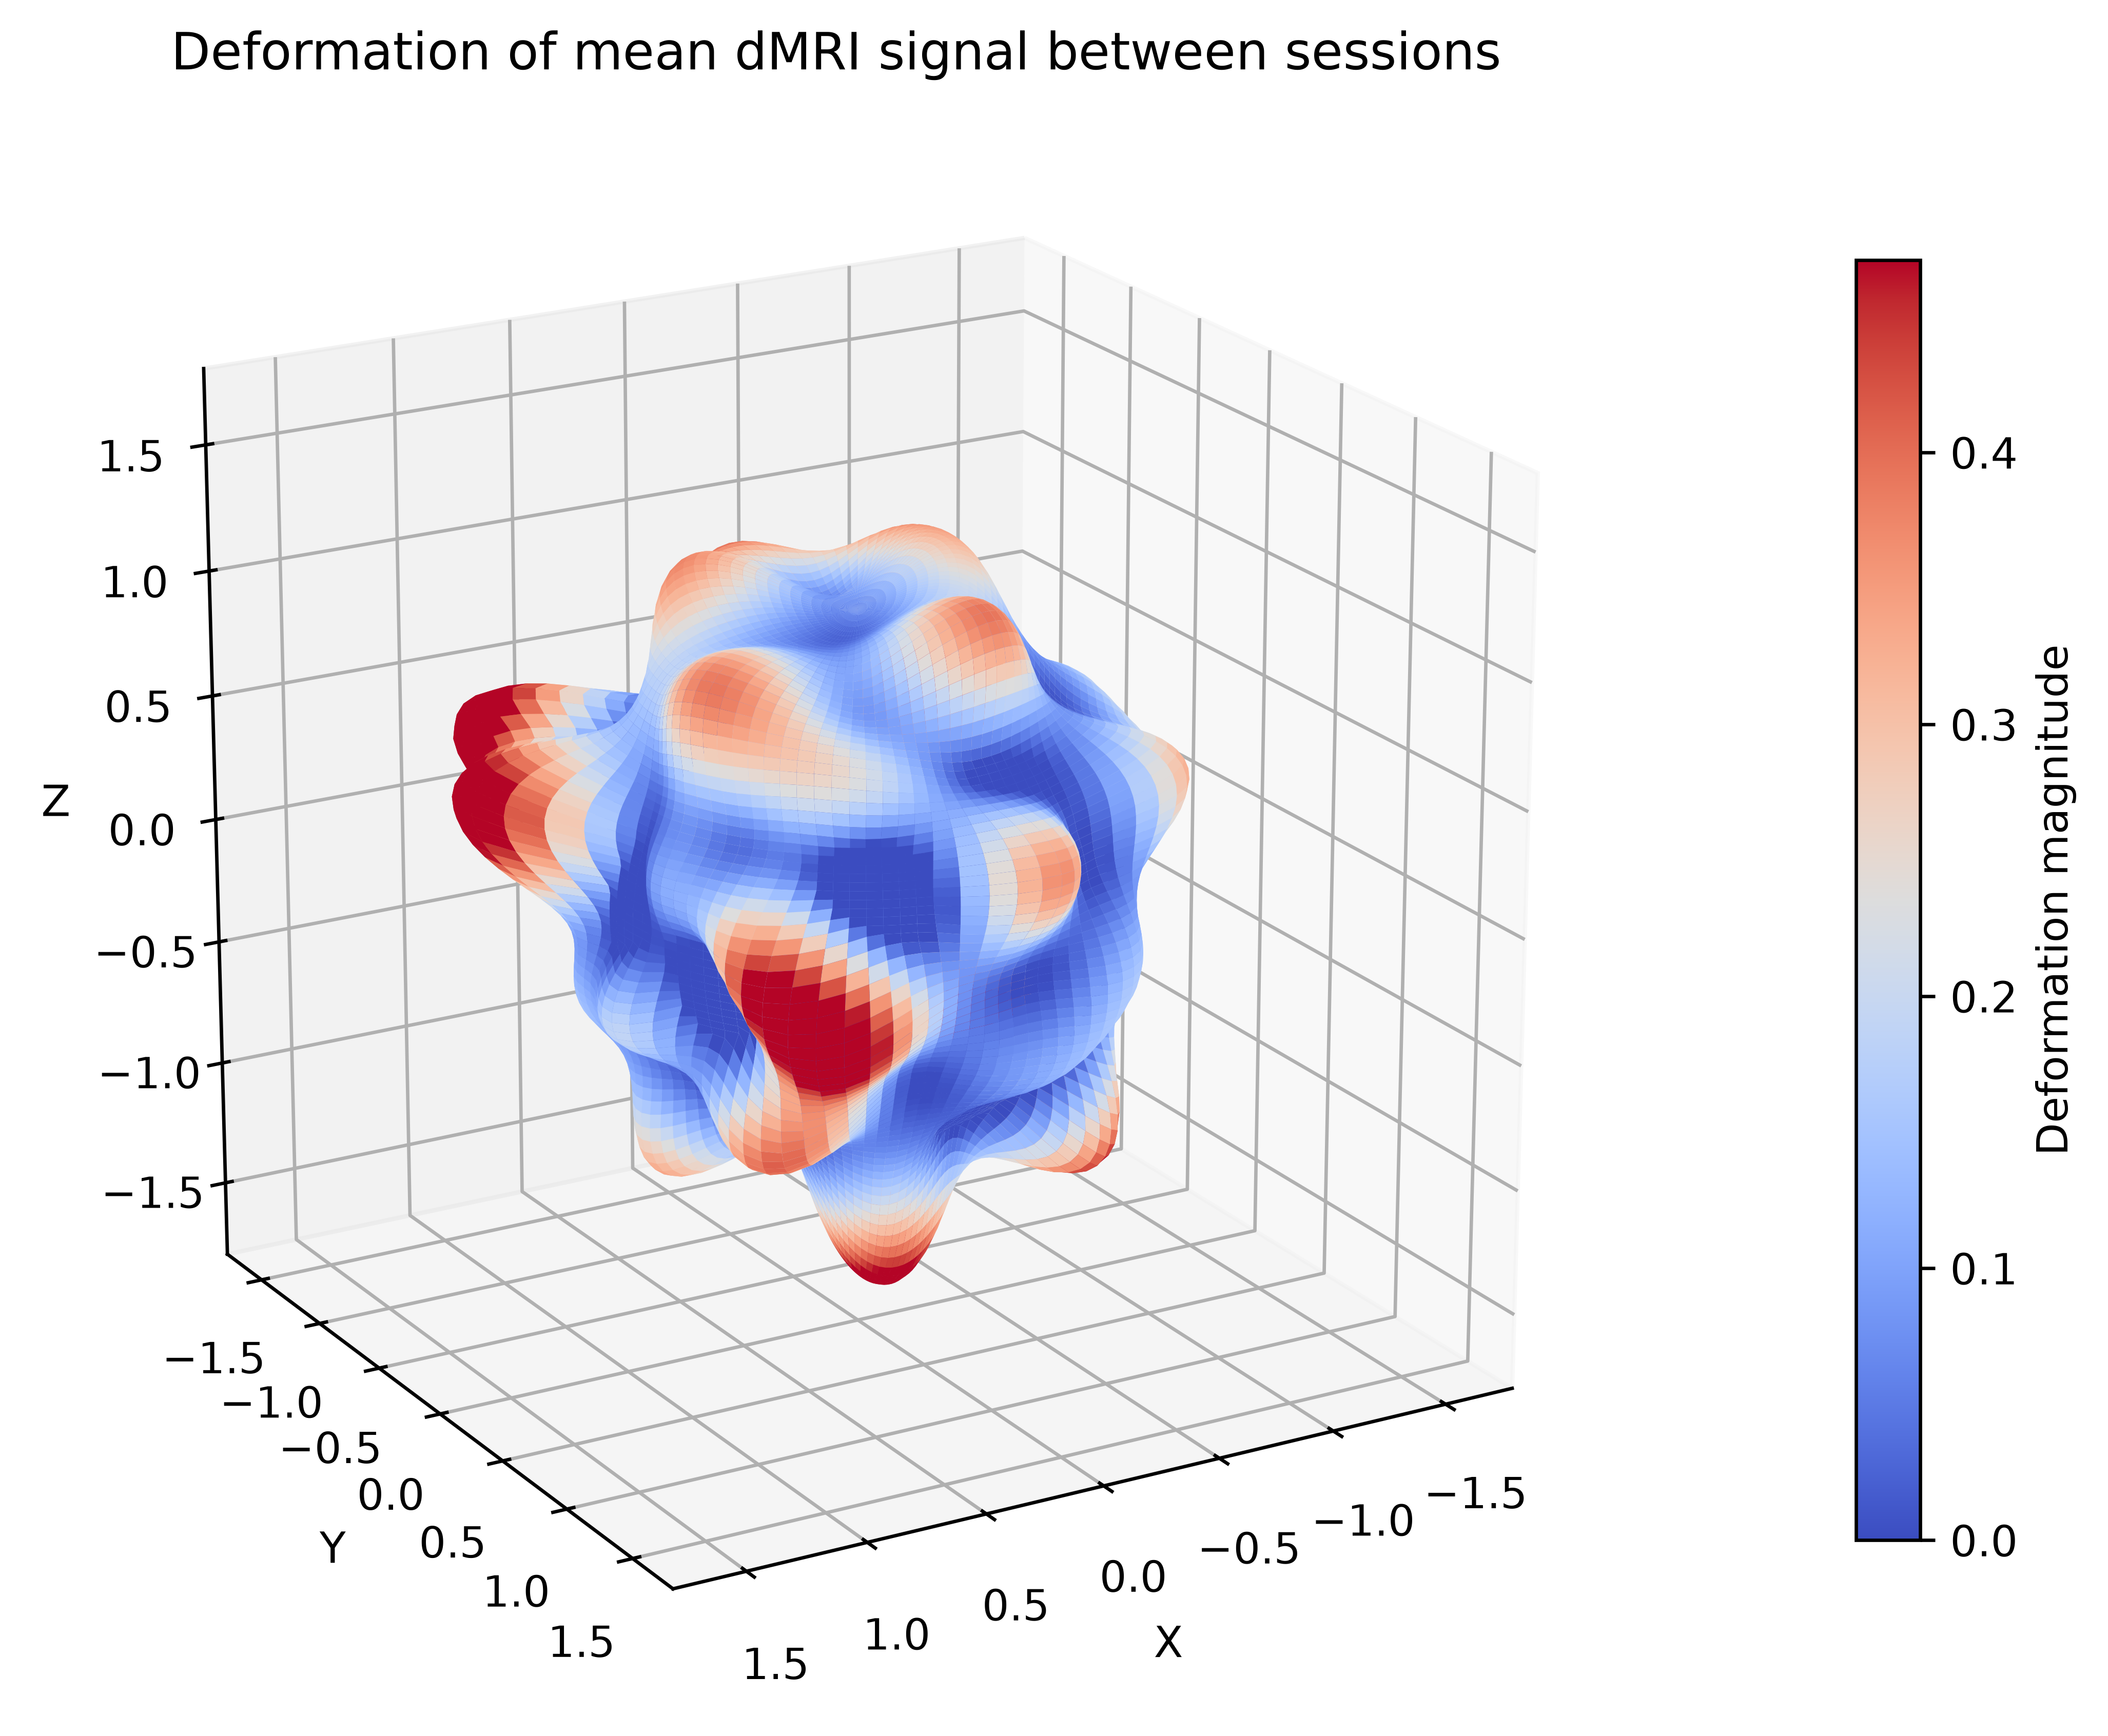

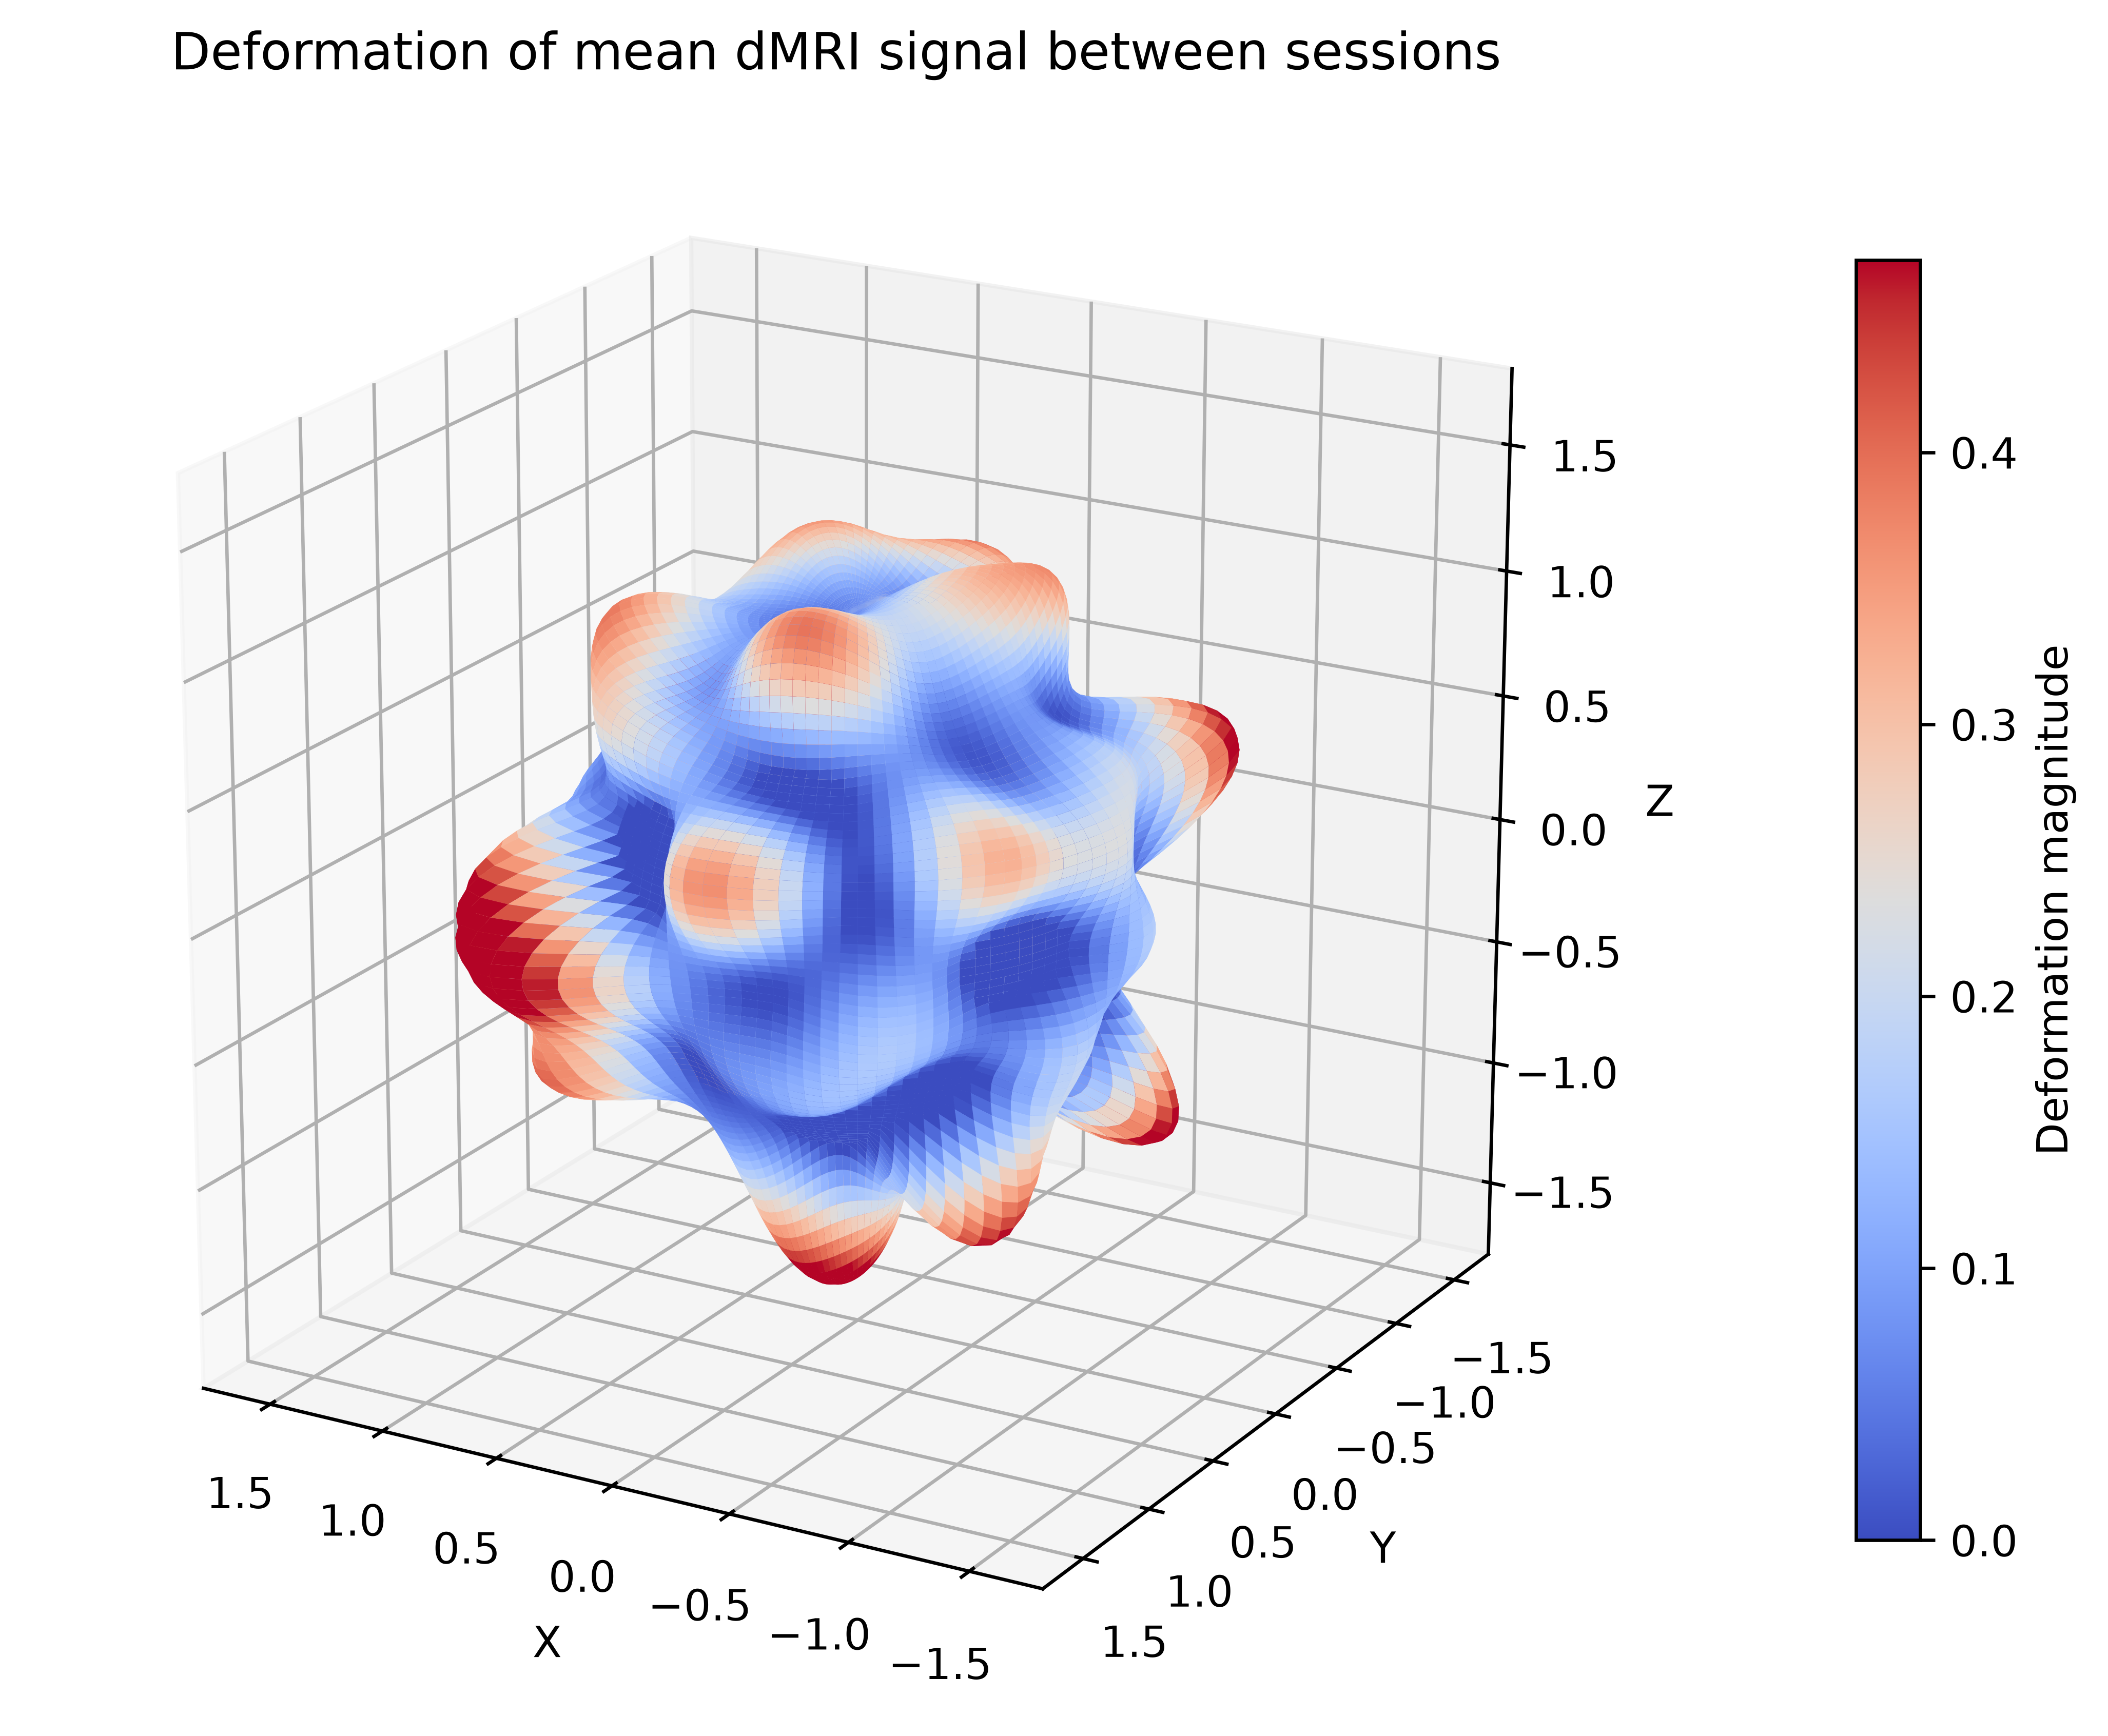

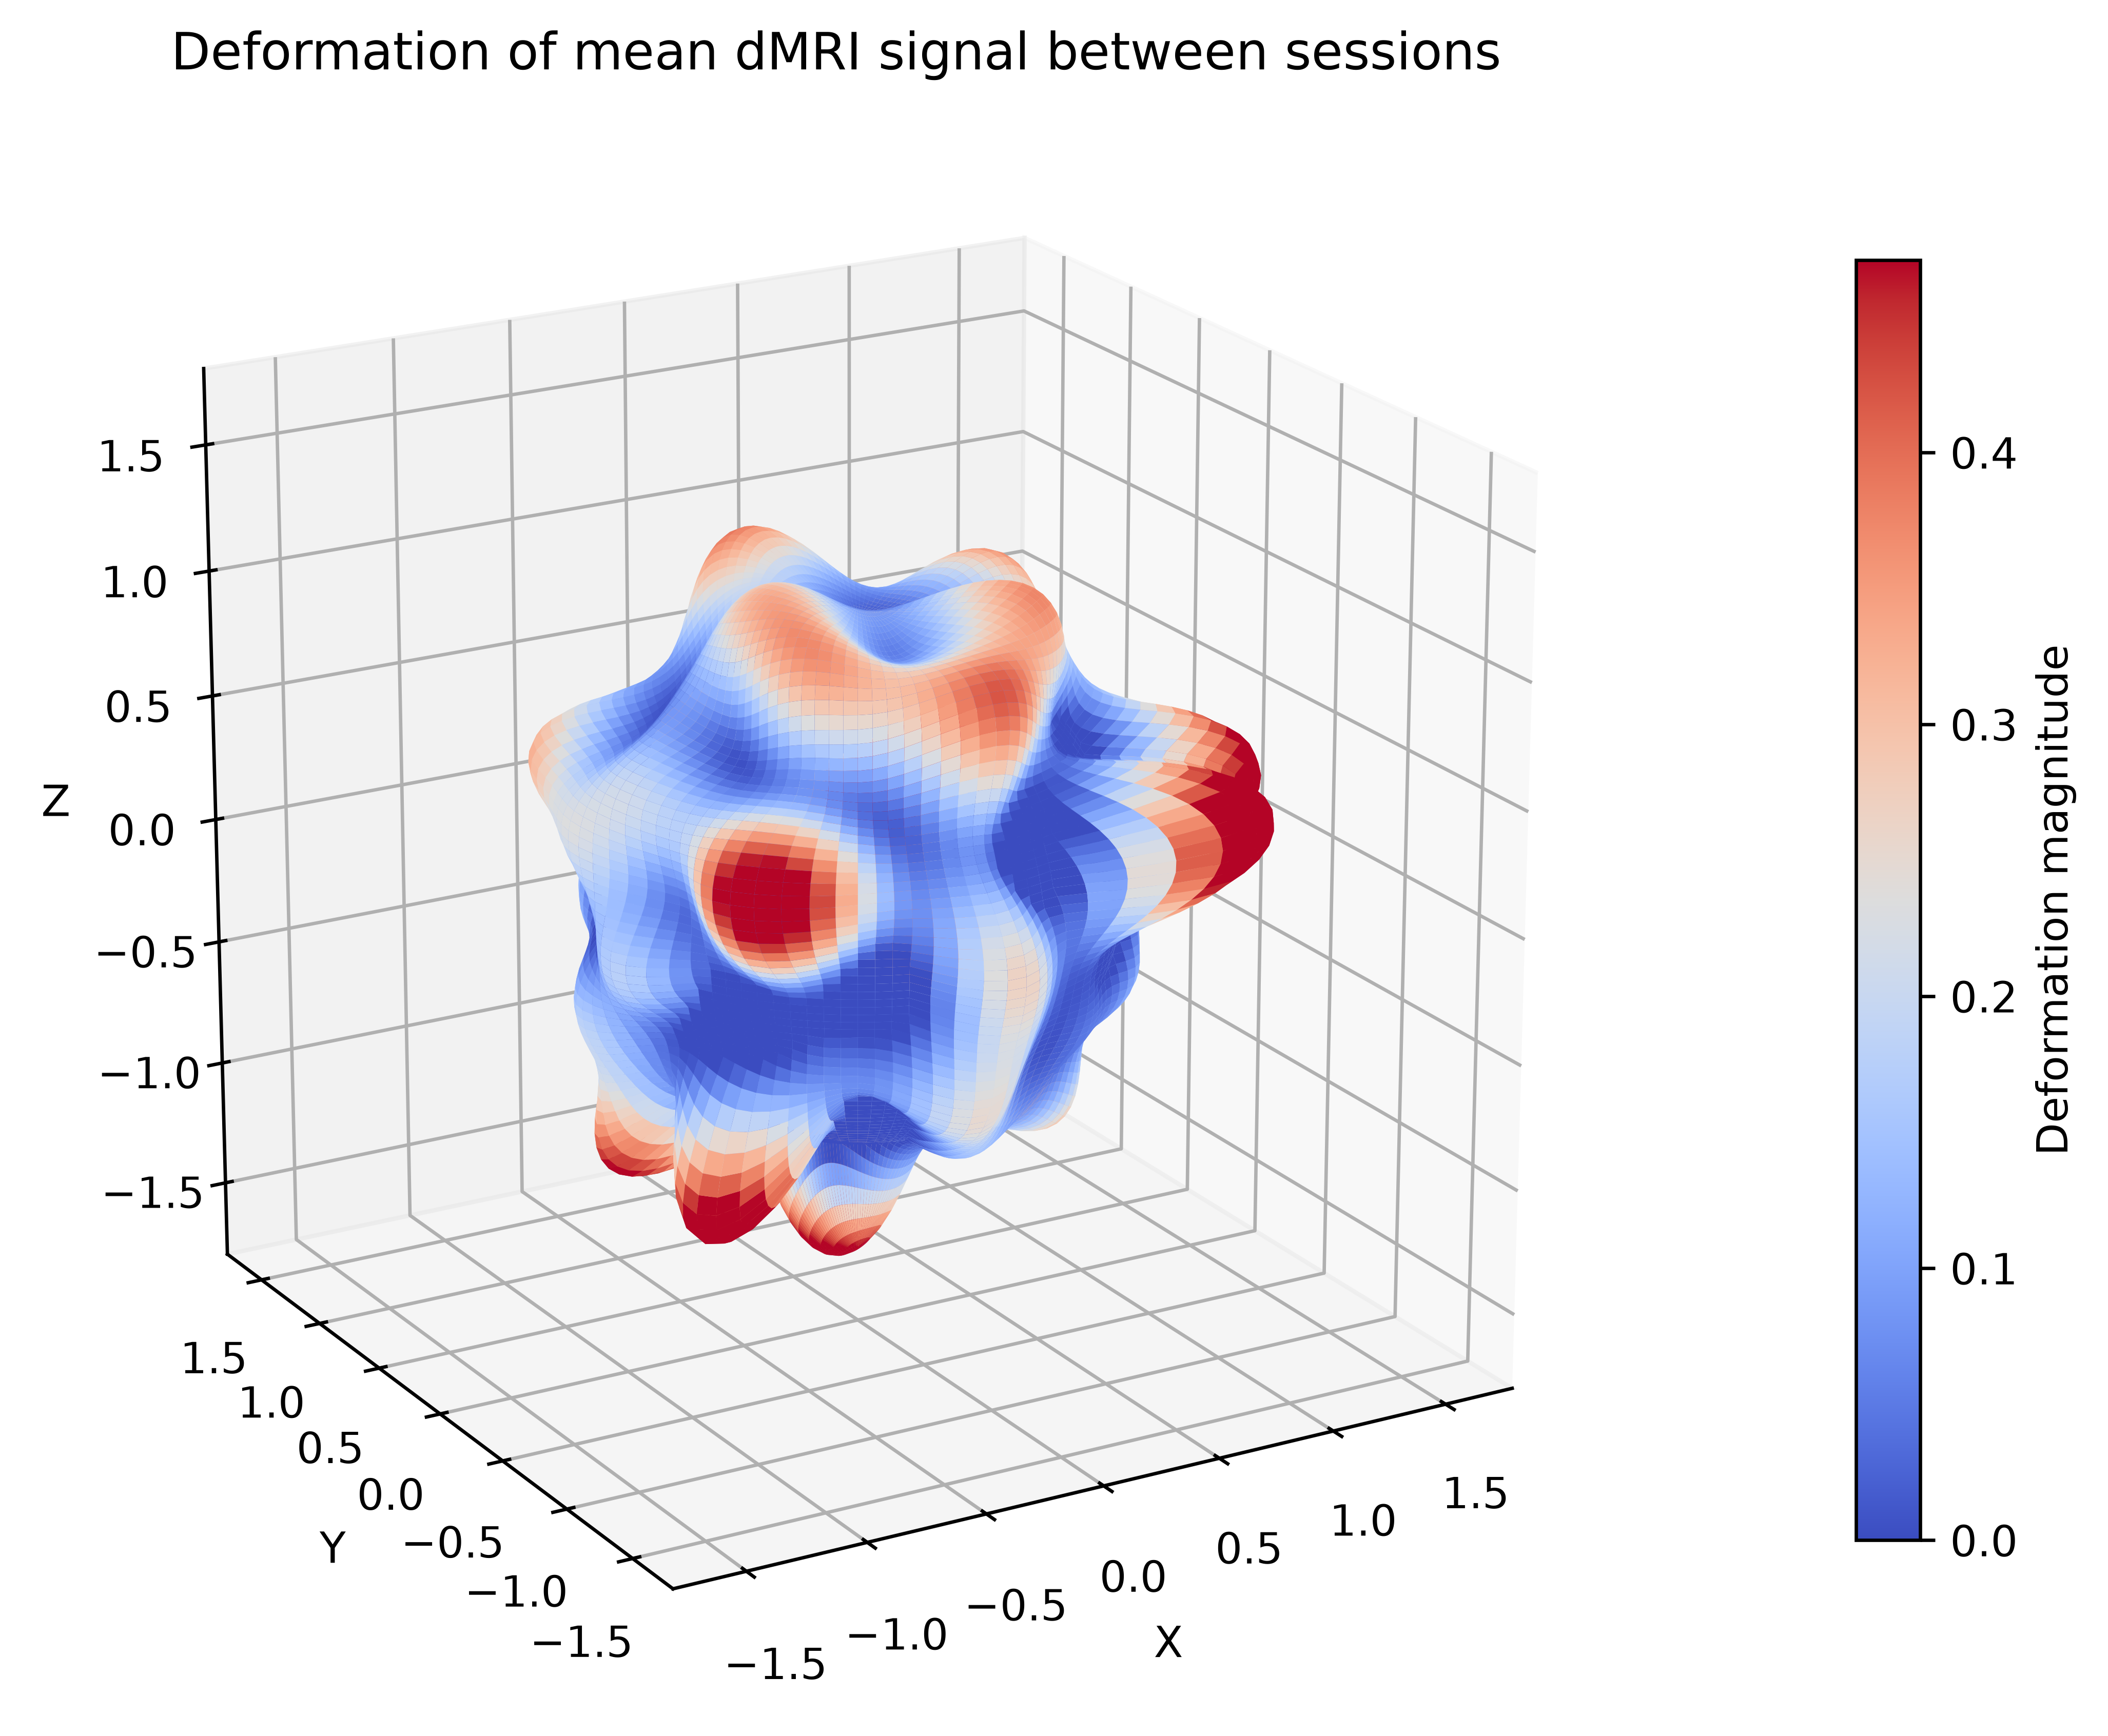

In [111]:
STEPs = [60, 120, 240]

for STEP in STEPs:
    DEFORM_STRENGTH = 1# 0.5 #ow much the most extreme |z| direction bulges the sphere outward
    # Fit a smooth scalar field over the sphere surface from your sampled directions

    """  
    From chat-gpt: An RBF (Radial Basis Function) is a way to take a set of scattered points where you know a value and create a smooth surface/function connecting them. 


    -> below the official documentation 
    An RBF is a scalar valued function in N-dimensional space whose value at can be expressed in terms of , where is the center of the RBF.
    An RBF interpolant for the vector of data values , which are from locations , is a linear combination of RBFs centered at plus a polynomial with a specified degree. The RBF interpolant is written as
    where is a matrix of RBFs with centers at evaluated at the points , and is a matrix of monomials, which span polynomials with the specified degree, evaluated at . The coefficients and are the solution to the linear equations and where is a non-negative 
    smoothing parameter that controls how well we want to fit the data. The data are fit exactly when the smoothing parameter is 0.

    The above system is uniquely solvable if the following requirements are met: must have full column rank. always has full column rank when degree is -1 or 0. When degree is 1, has full column rank if the data point locations are not all collinear (N=2), coplanar (N=3), etc.
    If kernel is ‘multiquadric’, ‘linear’, ‘thin_plate_spline’, ‘cubic’, or ‘quintic’, then degree must not be lower than the minimum value listed above. If smoothing is 0, then each data point location must be distinct.
    When using an RBF that is not scale invariant (‘multiquadric’, ‘inverse_multiquadric’, ‘inverse_quadratic’, or ‘gaussian’), an appropriate shape parameter must be chosen (e.g., through cross validation). Smaller values for the shape parameter correspond to wider RBFs. 
    The problem can become ill-conditioned or singular when the shape parameter is too small. The memory required to solve for the RBF interpolation coefficients increases quadratically with the number of data points, which can become impractical when interpolating 
    more than about a thousand data points. To overcome memory limitations for large interpolation problems, the neighbors argument can be specified to compute an RBF interpolant for each evaluation point using only the nearest data points.

    ---------------------------
    RBF interpolant for the vector of data values :math:`d`, which are from
        locations :math:`y`, is a linear combination of RBFs centered at :math:`y`
        plus a polynomial with a specified degree. The RBF interpolant is written
        as

        .. math::
            f(x) = K(x, y) a + P(x) b,

        where :math:`K(x, y)` is a matrix of RBFs with centers at :math:`y`
        evaluated at the points :math:`x`, and :math:`P(x)` is a matrix of
        monomials, which span polynomials with the specified degree, evaluated at
        :math:`x`. The coefficients :math:`a` and :math:`b` are the solution to the
        linear equations

        .. math::
            (K(x, y) + \\lambda I) a + P(y) b = d

        and

        .. math::
            P(y)^T a = 0,

        where :math:`\\lambda` is a non-negative smoothing parameter that controls
        how well we want to fit the data. The data are fit exactly when the
        smoothing parameter is 0.

        The above system is uniquely solvable if the following requirements are
        met:

        - :math:`P(y)` must have full column rank. :math:`P(y)` always has full
        column rank when `degree` is -1 or 0. When `degree` is 1,
        :math:`P(y)` has full column rank if the data point locations are not
        all collinear (N=2), coplanar (N=3), etc.
        - If `kernel` is 'multiquadric', 'linear', 'thin_plate_spline',
        'cubic', or 'quintic', then `degree` must not be lower than the
        minimum value listed above.
        - If `smoothing` is 0, then each data point location must be distinct.

        When using an RBF that is not scale invariant ('multiquadric',
        'inverse_multiquadric', 'inverse_quadratic', or 'gaussian'), an appropriate
        shape parameter must be chosen (e.g., through cross validation). Smaller
        values for the shape parameter correspond to wider RBFs. The problem can
        become ill-conditioned or singular when the shape parameter is too small.

        The memory required to solve for the RBF interpolation coefficients
        increases quadratically with the number of data points, which can become
        impractical when interpolating more than about a thousand data points.
        To overcome memory limitations for large interpolation problems, the
        `neighbors` argument can be specified to compute an RBF interpolant for
        each evaluation point using only the nearest data points.

    """
    rbf = RBFInterpolator(directions, weights, kernel="gaussian", epsilon=EPSILON, smoothing=0.01)#thin_plate_spline

    # Build a fine sphere mesh to evaluate the fitted field on
    n_theta, n_phi = 100, 100
    theta = np.linspace(0, np.pi, n_theta)
    phi = np.linspace(0, 2 * np.pi, n_phi)
    theta_grid, phi_grid = np.meshgrid(theta, phi)

    x_unit = np.sin(theta_grid) * np.cos(phi_grid)
    y_unit = np.sin(theta_grid) * np.sin(phi_grid)
    z_unit = np.cos(theta_grid)

    mesh_points = np.stack([x_unit.ravel(), y_unit.ravel(), z_unit.ravel()], axis=-1)
    deform_field = rbf(mesh_points).reshape(x_unit.shape)
    deform_field = np.clip(deform_field, 0, None)  # no inward dips from interpolation overshoot

    radius = 1.0 + deform_field *  DEFORM_STRENGTH 

    x_def = radius * x_unit
    y_def = radius * y_unit
    z_def = radius * z_unit

    # Sampled directions scaled to match the deformation (shared by both plots)
    points = directions * (1.0 + DEFORM_STRENGTH * weights)[:, None]

    max_extent =  0.8 + DEFORM_STRENGTH

    # ---------- Static (matplotlib) ----------


    # 1) Stretch the data over the full colormap
    #    (percentiles make it robust to outliers)
    vmin, vmax = np.percentile(deform_field, [1, 95])
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    # 2) Choose a colormap with more variation, and more discrete levels
    cmap = plt.get_cmap("coolwarm", 2048)   # alternatives: "nipy_spectral", "jet", "plasma", "inferno"

    facecolors = cmap(norm(deform_field))

    fig = plt.figure(figsize=(9, 9), dpi=600)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        x_def, y_def, z_def,
        facecolors=facecolors,
        rstride=1, cstride=1,
        linewidth=0, antialiased=True, shade=False,
    )

    # 3) Colorbar so the extended range is readable
    mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1, label="Deformation magnitude")
    ax.scatter(*points.T, c="black", s=10, alpha=0.001)

    ax.set_xlim(-max_extent, max_extent)
    ax.set_ylim(-max_extent, max_extent)
    ax.set_zlim(-max_extent, max_extent)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect([2, 2, 2])
    ax.view_init(elev=20, azim=STEP)
    ax.set_title("Deformation of mean dMRI signal between sessions")

    plt.show()
    fig.savefig(f"/home/malberti/Unix_Folders/SWEEP2/potato_plot{STEP}_LASTEST_.png", dpi=600, bbox_inches="tight")

In [ ]:
out_path = "/home/malberti/Unix_Folders/SWEEP2/potato_plot_directions_z.csv"

df = pd.DataFrame({
    "x": directions[:, 0],
    "y": directions[:, 1],
    "z": directions[:, 2],
    "z_score": z,
})
df.to_csv(out_path, index=False)
